In [1]:
from transformers import DetrForObjectDetection, DetrConfig, DetrImageProcessor, Trainer, TrainingArguments, ResNetConfig
from torch.utils.data import random_split
from dataset import DartsDataset
from torchvision import transforms
from PIL import Image, ImageDraw
from util import prepare_6_channel, CustomDetrImageProcessor
import torch
from torchvision.datasets import CocoDetection
import numpy as np
import cv2
%load_ext autoreload
%autoreload 2

c:\Users\Public\anaconda3\envs\darts\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
id2label = {
    0: "right",
    1: "top",
    2: "left",
    3: "bottom",
    4: "dart",
}
label2id = {v: k for k, v in id2label.items()}

In [3]:
model = DetrForObjectDetection.from_pretrained(
    "center_scale/checkpoint-7600/", 
    auxiliary_loss=True, 
    num_queries=100,
    num_labels=5,  
    bbox_loss_coefficient=4.0,
    giou_loss_coefficient=1.0,
    giou_cost=0.0,
    eos_coefficient = 0.06,
    ignore_mismatched_sizes=True,
    id2label=id2label,
    label2id=label2id,
    num_channels=3,
    )

c:\Users\Public\anaconda3\envs\darts\Lib\site-packages\torch\nn\modules\module.py:2397: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
c:\Users\Public\anaconda3\envs\darts\Lib\site-packages\torch\nn\modules\module.py:2397: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
c:\Users\Public\anaconda3\envs\darts\Lib\site-packages\torch\nn\modules\module.py:2397: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current 

In [4]:
image_processor = CustomDetrImageProcessor(size={"shortest_edge": 768, "longest_edge": 768})

In [5]:
# prepare_6_channel(model)
# from safetensors.torch import load_file
# model.load_state_dict(load_file("dual_input/checkpoint-6000/model.safetensors"))

In [6]:
for k, v in model.named_parameters():
    print(k, v.shape, v.requires_grad, v[0, :, :, 0])
    break


model.backbone.conv_encoder.model.conv1.weight torch.Size([64, 3, 7, 7]) False tensor([[ 0.0133,  0.0041,  0.0223,  0.0232, -0.0009,  0.0036, -0.0800],
        [-0.0185, -0.0077, -0.0460, -0.0386,  0.0288,  0.0829, -0.0073],
        [-0.0183, -0.0101, -0.0635, -0.0280,  0.0258,  0.0730, -0.0064]])


In [7]:
dirs = [f'3D/scene/rendered/imgs_{i}' for i in range(6)]
dataset = DartsDataset(dirs=dirs, random_rescale=True, is_synthetic=True)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=generator)
len(train_dataset), len(test_dataset)

(19200, 4800)

In [8]:
test_dataset = DartsDataset(dirs=[f'my_unlabelled/vids/frames_000{i}' for i in range(8)], random_rescale=False, random_rotation=False, resize_to=768, is_synthetic=False)

In [9]:
import torchvision.transforms.functional as TF

In [10]:
colors = ["red", "blue", "green", "yellow", "orange"]

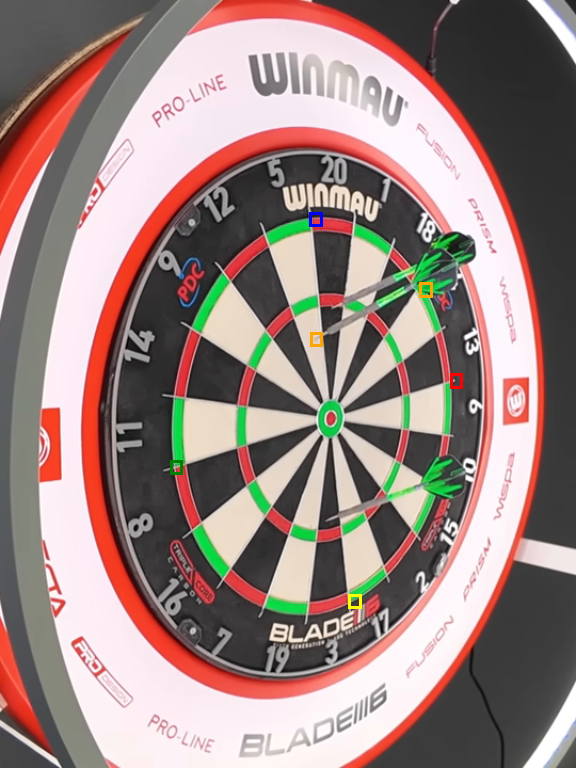

In [34]:
image, targets, t_image, t_targets = test_dataset[np.random.randint(len(test_dataset))]
inputs = image_processor(images=image, annotations=targets, return_tensors="pt", do_resize=False)
outputs = model(**inputs)
# reference_outputs = model(**reference_inputs)
# outputs.logits -= reference_outputs.logits
target_sizes = torch.tensor([image.size[::-1]])
results = image_processor.post_process_object_detection(outputs, threshold=0.0, target_sizes=target_sizes)[0]

boxes, labels, scores = results["boxes"].detach(), results["labels"].detach(), results["scores"].detach()
size = 768
corners = np.array([boxes[outputs["logits"][0, :, corner].argmax().item()] for corner in range(4)])
src = np.stack(((corners[:, 0] + corners[:, 2])/2, (corners[:, 1] + corners[:, 3])/2), axis=1)
tgt = np.array([[0.88, 0.5], [0.5, 0.12], [0.12, 0.5], [0.5, 0.88]]) * size
transform, _ = cv2.findHomography(src, tgt)
transformed_image = Image.fromarray(cv2.warpPerspective(np.array(image), transform, (size, size)))


# inputs = image_processor(images=transformed_image, return_tensors="pt", do_resize=False, pad_size={"height": 768, "width": 768})
# outputs = model(**inputs)
# target_sizes = torch.tensor([image.size[::-1]])
# results = image_processor.post_process_object_detection(outputs, threshold=0.5, target_sizes=target_sizes)[0]

draw = ImageDraw.Draw(image)
results = image_processor.post_process_object_detection(outputs, threshold=0.75, target_sizes=target_sizes)[0]
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    draw.rectangle(box.tolist(), outline=colors[label], width=3)

# for i, corner in enumerate(corners):
#     draw.rectangle(corner.tolist(), outline=colors[i], width=3)
image

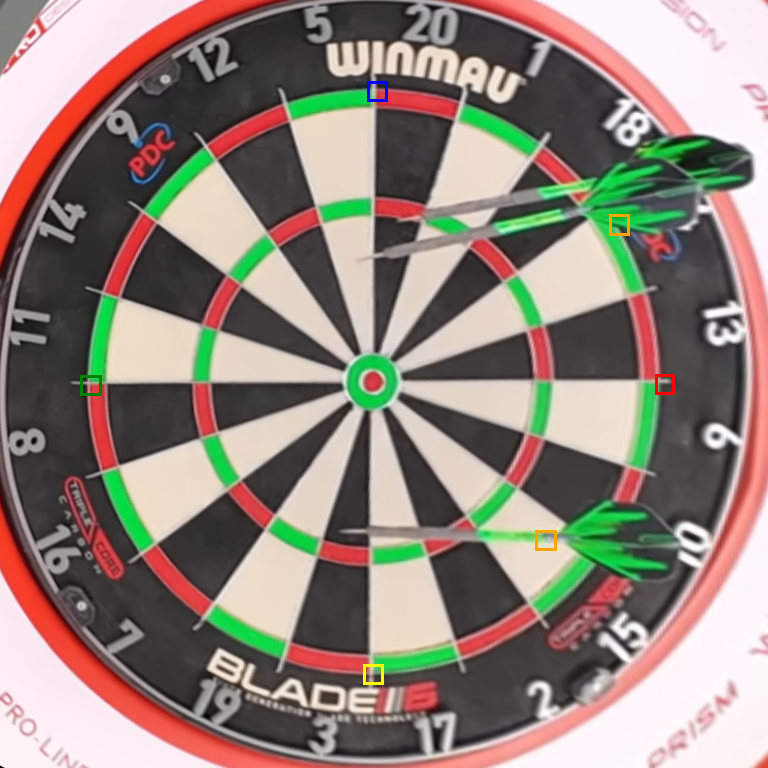

In [35]:
inputs = image_processor(images=transformed_image, return_tensors="pt", do_resize=False)
outputs = model(**inputs)
target_sizes = torch.tensor([transformed_image.size[::-1]])
results = image_processor.post_process_object_detection(outputs, threshold=0.75, target_sizes=target_sizes)[0]

draw = ImageDraw.Draw(transformed_image)
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    draw.rectangle(box.tolist(), outline=colors[label], width=3)

# for i, corner in enumerate(corners):
#     draw.rectangle(corner.tolist(), outline=colors[i], width=3)
transformed_image